# Eyelink 1000Hz Data Blink Removal and PCHIP Interpolation

This notebook loads parsed EyeLink 1000Hz data from `out/`, identifies blinks (where pupil tracking is lost), expands the blink mask to cover the closing and opening phases of the eyelid, and performs **PCHIP (Piecewise Cubic Hermite Interpolating Polynomial)** interpolation to smoothly reconstruct the missing data.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 7)

In [2]:
# Load the parsed EyeLink data from out/
input_csv = "../../../out/260611.csv"
if not os.path.exists(input_csv):
    input_csv = "out/260611.csv"  # Fallback if run from a different cwd

df = pd.read_csv(input_csv)
print(f"Loaded {input_csv} with shape: {df.shape}")
df.head()

Loaded ../../../out/260611.csv with shape: (27512, 7)


,timestamp,elasped_ms,elasped_sec,blue_active,gaze_x,gaze_y,pupil_size
0,866527,0,0.000,0,946.9,520.2,11334.0
1,866528,1,0.001,0,947.0,521.2,11337.0
2,866529,2,0.002,0,947.1,521.2,11337.0
3,866530,3,0.003,0,947.1,520.7,11336.0
4,866531,4,0.004,0,947.1,520.3,11335.0


In [3]:
# Configuration for blink interpolation
SLIDING_WINDOW_SIZE = 200  # Number of rows to roll (center=True) to expand blink mask
BLINK_THRESHOLD = 500    # Pupil size below this is considered a blink/loss

# 1. Create a copy of the raw pupil size to be cleaned
df['cleaned_pupil_size'] = df['pupil_size'].astype(float)

# 2. Identify blink spikes (where the tracker lost the pupil, i.e., size is 0 or extremely low)
blink_mask = df['cleaned_pupil_size'] < BLINK_THRESHOLD
print(f"Number of raw blink/dropout samples: {blink_mask.sum()} out of {len(df)}")

# 3. Expand the blink mask to clean the eyelid closing/opening artifacts
# The eyelid partially covers the pupil just before and after the 0, creating bad data.
# We use a rolling window to expand the blink mask slightly (e.g. 4 samples before and after).
expanded_blink_mask = blink_mask.rolling(window=SLIDING_WINDOW_SIZE, center=True, min_periods=1).max().astype(bool)
print(f"Number of expanded blink/dropout samples to interpolate: {expanded_blink_mask.sum()}")

# 4. Erase the blink data by setting to NaN
df.loc[expanded_blink_mask, 'cleaned_pupil_size'] = np.nan

# 5. Bridge the gaps using PCHIP interpolation
# PCHIP (Piecewise Cubic Hermite Interpolating Polynomial) preserves monotonicity and avoids overshoot.
df['cleaned_pupil_size'] = df['cleaned_pupil_size'].interpolate(method='pchip', limit_area='inside')
df['cleaned_pupil_size'] = df['cleaned_pupil_size'].ffill().bfill()


Number of raw blink/dropout samples: 1230 out of 27512
Number of expanded blink/dropout samples to interpolate: 2026


In [4]:
# Save the cleaned DataFrame back to the out/ folder
output_path = f"../../../out/{os.path.basename(input_csv)[:-4]}_cleaned"
if not os.path.exists("../../../out"):
    output_path = f"out/{os.path.basename(input_csv)[:-4]}_cleaned"

df.to_csv(output_path + '.csv', index=False)
df.to_excel(output_path + '.xlsx', index=False)
print(f"Saved cleaned data with 'cleaned_pupil_size' column back to {output_path}")

Saved cleaned data with 'cleaned_pupil_size' column back to ../../../out/260611_cleaned


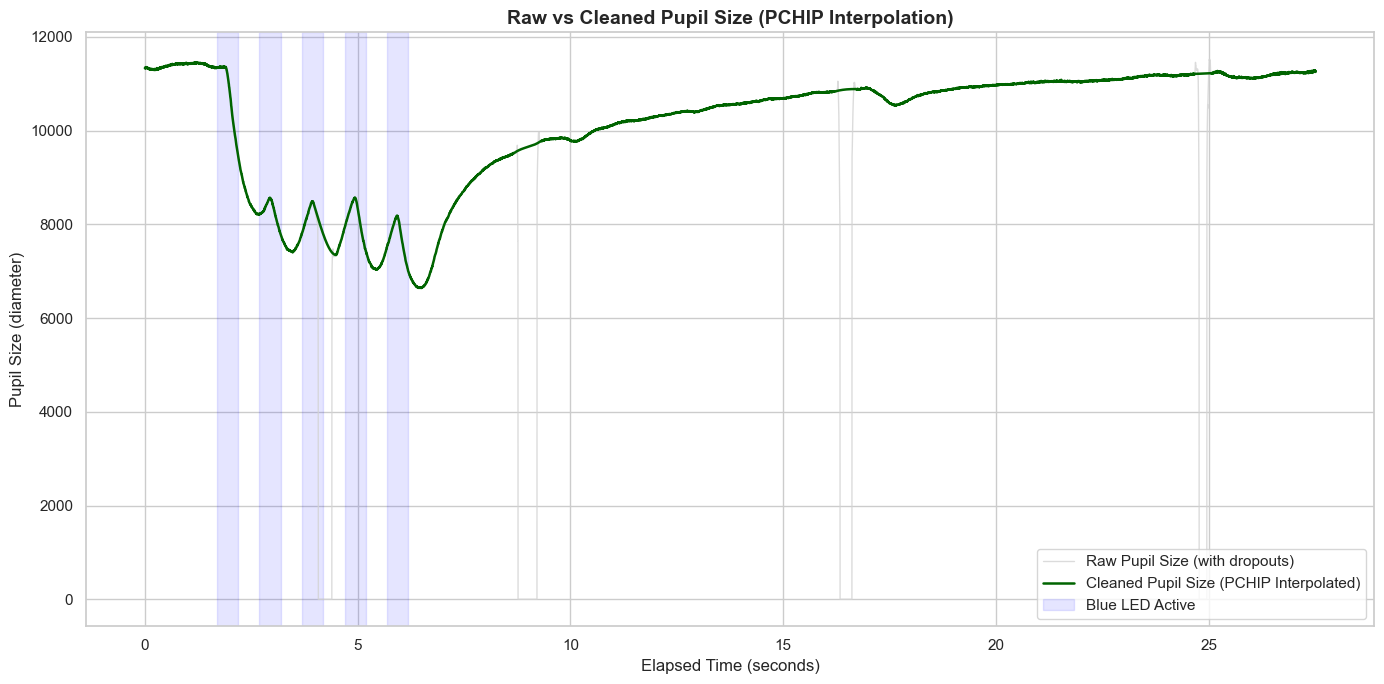

In [5]:
# Plotting raw vs cleaned data to verify the interpolation
plt.figure(figsize=(14, 7))

# Plot raw pupil size
plt.plot(df['elasped_sec'], df['pupil_size'], label='Raw Pupil Size (with dropouts)', color='lightgray', alpha=0.8, linewidth=1)

# Plot cleaned pupil size
plt.plot(df['elasped_sec'], df['cleaned_pupil_size'], label='Cleaned Pupil Size (PCHIP Interpolated)', color='darkgreen', linewidth=1.8)

# Overlay blue active intervals as shaded background
transitions = df['blue_active'].diff().fillna(0)
starts = df.loc[transitions == 1, 'elasped_sec'].values
ends = df.loc[transitions == -1, 'elasped_sec'].values
if len(starts) > len(ends):
    ends = np.append(ends, df['elasped_sec'].max())

for start, end in zip(starts, ends):
    plt.axvspan(start, end, color='blue', alpha=0.1, label='Blue LED Active' if start == starts[0] else "")

plt.title('Raw vs Cleaned Pupil Size (PCHIP Interpolation)', fontsize=14, fontweight='bold')
plt.xlabel('Elapsed Time (seconds)', fontsize=12)
plt.ylabel('Pupil Size (diameter)', fontsize=12)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()